In [1]:
import importlib
import peak_gene_utils
importlib.reload(peak_gene_utils)
from peak_gene_utils import *

import time
import joblib

from utils import *
import squidpy as sq
import os

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/anndata

## Load data

### Annotate cCRE df with three nearest genes

In [2]:
atac = sc.read_h5ad("desc_normalized_atac_peaks.h5ad")
expr = sc.read_h5ad("desc_normalized_rna.h5ad")

In [3]:
niche_pca_anno = sc.read_h5ad("../../h5ad_files/niche_pca_annotated_sp.h5ad")

In [4]:
expr.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()
atac.obs["niche_pca_leiden"] = niche_pca_anno.obs["leiden"].copy()

In [5]:
# get nichePCA pca matrix
X_npca = np.load("../X_npca.npy")
expr.obsm["X_npca"] = X_npca

## Run Descart

In [6]:
#num_select_peak = 10000
num_select_peak = 20000
seed_base = 1
tf = 'tfidf2'
pc = 10
k = 20
similarity = 'cosine'
iter_time = 4
spmethod = 'threshold'
neighbor = 5
sp_dist = 'recip'
pre_select = 'highest'
peaks_num = 50000
distance = 'euclidean'
r = 0.5


start_time = time.time()

#adata = sc.AnnData(adata_raw.X,dtype = 'float32')
idx, sorted_index, simi_matrix, idx_all, scores, selected_peaks_data,similarity_matrix_acb, similarity_matrix_spatial = run_descart(atac, num_select_peak, seed_base=seed_base, tfidf=tf, ifPCA=True, pc=pc, k=k, similarity=similarity, iters=iter_time, spmethod=spmethod,neighbor=neighbor,sp_dist=sp_dist, pre_select=pre_select, peaks_num=peaks_num, distance=distance,r=r)

end_time = time.time()

elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")

descart_output = {
    'idx': idx,
    'sorted_index': sorted_index,
    'simi_matrix': simi_matrix,
    'idx_all': idx_all,
    'scores': scores,
    'selected_peaks_data': selected_peaks_data,
    'similarity_matrix_acb': similarity_matrix_acb,
    'similarity_matrix_spatial': similarity_matrix_spatial
}

joblib.dump(descart_output, 'module_cache/descart_output_r0.5_20k.pkl')  # You can customize the filename based on parameters
print("Saved run_descart output.")


AnnData object with n_obs × n_vars = 5274 × 72148
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'cell_id', 'centroid_x', 'centroid_y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_50_genes', 'uniform_density', 'rna_count_based_density', 'niche_pca_leiden'
    var: 'chrom', 'start', 'end', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'is_training'
    uns: 'files', 'gearyC', 'spatial_neighbors'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'
(5274, 72148)
(5274, 5274)
(5274, 10)
0.0
compute scores
scores:
[ 8990.12582589  8990.16030101  8990.19850324 ... 27729.26777118
 29966.56325173 30885.72792664]
(5274, 5274)
(5274, 10)
0.0
compute scores
scores:
[ 9134.19009442  9134.26568453  9134.34831228 ... 26532.57236401
 29978.92749663 30680.97303614]
(5274, 5274)
(5274, 10)
0.0
com

In [7]:
'''
descart_output = joblib.load('module_cache/descart_output_r0.5.pkl')

# Unpack the variables
idx = descart_output['idx']
sorted_index = descart_output['sorted_index']
simi_matrix = descart_output['simi_matrix']
idx_all = descart_output['idx_all']
scores = descart_output['scores']
selected_peaks_data = descart_output['selected_peaks_data']
similarity_matrix_acb = descart_output['similarity_matrix_acb']
similarity_matrix_spatial = descart_output['similarity_matrix_spatial']

print("Loaded cached output.")
'''

'\ndescart_output = joblib.load(\'module_cache/descart_output_r0.5.pkl\')\n\n# Unpack the variables\nidx = descart_output[\'idx\']\nsorted_index = descart_output[\'sorted_index\']\nsimi_matrix = descart_output[\'simi_matrix\']\nidx_all = descart_output[\'idx_all\']\nscores = descart_output[\'scores\']\nselected_peaks_data = descart_output[\'selected_peaks_data\']\nsimilarity_matrix_acb = descart_output[\'similarity_matrix_acb\']\nsimilarity_matrix_spatial = descart_output[\'similarity_matrix_spatial\']\n\nprint("Loaded cached output.")\n'

In [8]:
start_time = time.time()
pdist_ = peak_modules_(selected_peaks_data=selected_peaks_data, similarity_matrix=simi_matrix, method='complete')
pdist_ = (pdist_+pdist_.T)/2
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.6f} seconds")
print("Peak modules calculation has been done.")

pdist_.shape

Running time: 31.028224 seconds
Peak modules calculation has been done.


(20000, 20000)

In [9]:
non_diagonal_values = pdist_[np.triu_indices(pdist_.shape[0], k=1)]
peak_similarity = np.copy(pdist_)
thd = np.percentile(non_diagonal_values, 99.5)
peak_similarity[peak_similarity > thd] = thd
peak_distance = thd - peak_similarity
np.fill_diagonal(peak_distance, 0)

## Get peak modules

/nfs/home/students/l.reich/tangram/src/Descart/utils.py:1081: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = sch.linkage(peak_distance, method=method)


Cluster labels: [1 3 2 ... 3 3 3]


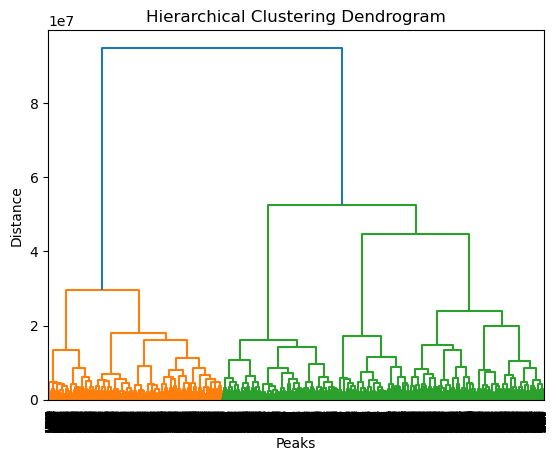

Number 1: Count = 1885, Proportion = 9.43%
Number 2: Count = 5162, Proportion = 25.81%
Number 3: Count = 4625, Proportion = 23.12%
Number 4: Count = 2916, Proportion = 14.58%
Number 5: Count = 5412, Proportion = 27.06%


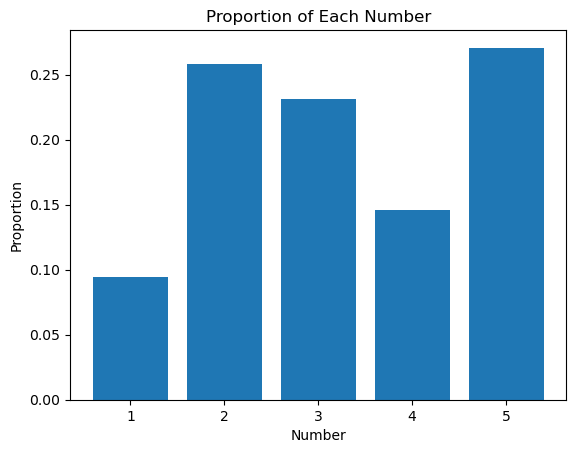

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


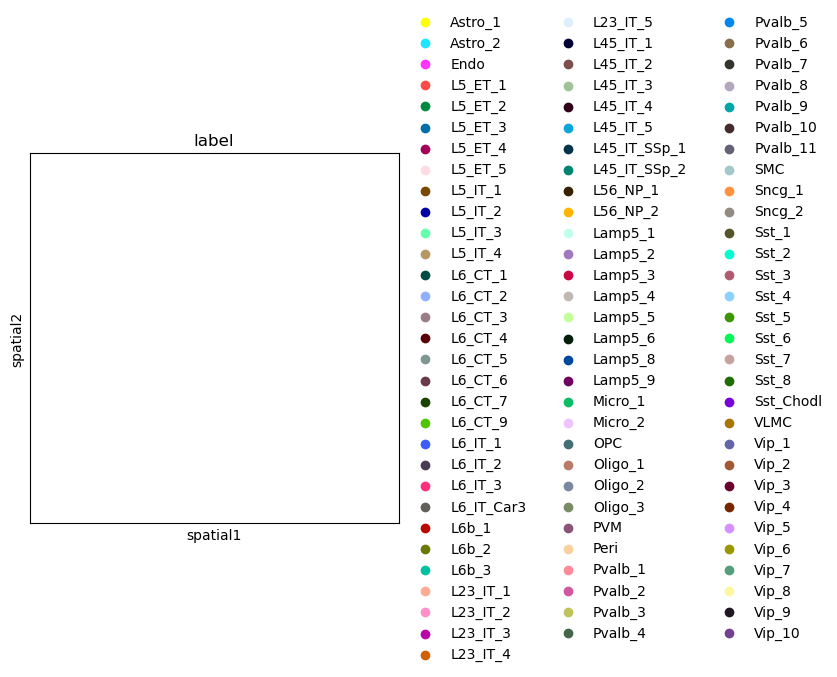

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


Number of peaks in module 1: 1885
Visualize peak module of label 1:
9999


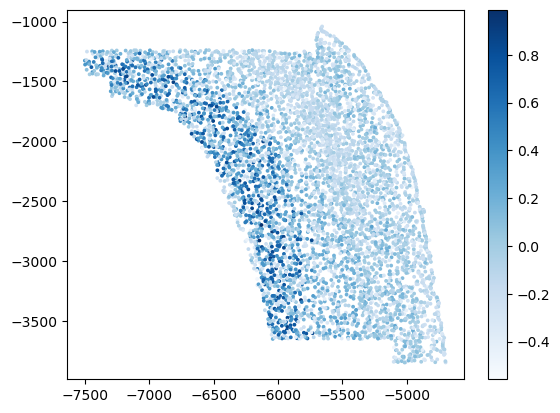

Number of peaks in module 2: 5162
Visualize peak module of label 2:
9999


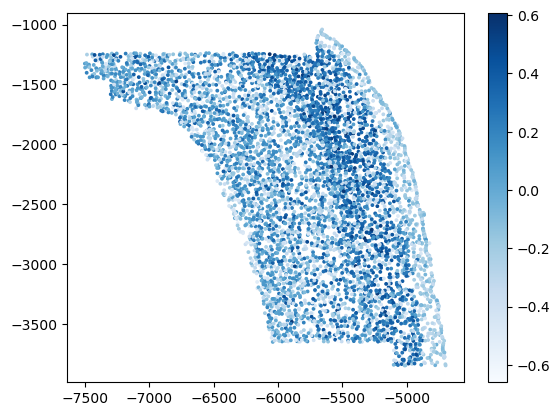

Number of peaks in module 3: 4625
Visualize peak module of label 3:
9999


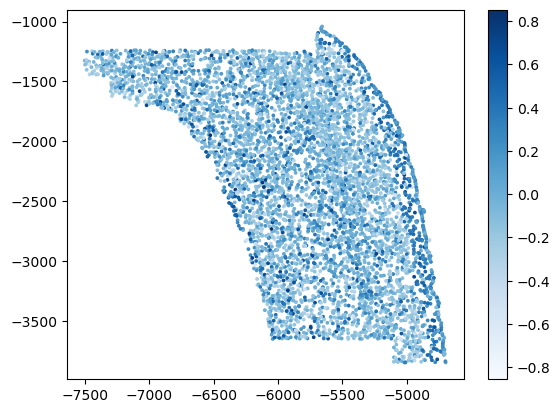

Number of peaks in module 4: 2916
Visualize peak module of label 4:
9999


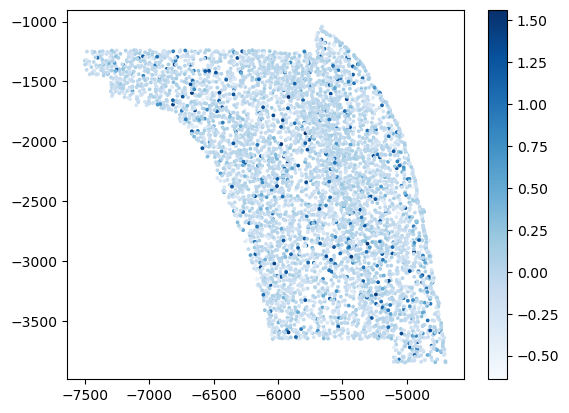

Number of peaks in module 5: 5412
Visualize peak module of label 5:
9999


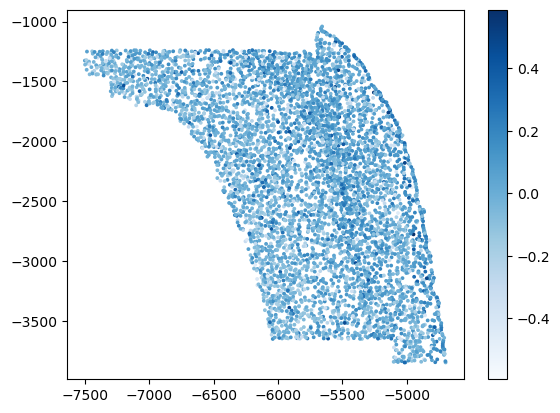

In [10]:
Z,labels = peak_module_cluster(atac,idx,peak_distance,"ward",num_clusters = 5)

In [11]:

cluster_output = {
    'Z': Z,
    'labels': labels
}

joblib.dump(cluster_output, 'module_cache/peak_modules_r0.5_k5_20k.pkl')
print("Saved peak module clustering output.")


Saved peak module clustering output.


In [12]:
'''
cluster_output = joblib.load('module_cache/peak_modules_r0.5_k5.pkl')

Z = cluster_output['Z']
labels = cluster_output['labels']

print("Loaded peak module clustering from cache.")
'''

'\ncluster_output = joblib.load(\'module_cache/peak_modules_r0.5_k5.pkl\')\n\nZ = cluster_output[\'Z\']\nlabels = cluster_output[\'labels\']\n\nprint("Loaded peak module clustering from cache.")\n'

In [13]:
def compute_linkage(peak_distance, method='ward'):
    return sch.linkage(peak_distance, method=method)

def get_cluster_labels(Z, num_clusters):
    return sch.fcluster(Z, t=num_clusters, criterion='maxclust')

In [14]:
# Use the existing AnnData with spatially variable peaks
# Ensure the accessibility matrix is log-transformed (if not already)
sc.pp.log1p(atac)

# Run rank_genes_groups on spatial domains
sc.tl.rank_genes_groups(atac, groupby="niche_pca_leiden", method="wilcoxon", use_raw=False)

# Extract the ranked peak names per domain
# This will return a recarray of shape (top_n, n_domains)
ranked_names = atac.uns['rank_genes_groups']['names']

# Convert to DataFrame
domains = ranked_names.dtype.names
ranked_df = pd.DataFrame({domain: ranked_names[domain] for domain in domains})

# Get indices in .var_names
ranked_indices = pd.DataFrame({
    domain: atac.var_names.get_indexer(ranked_df[domain])
    for domain in domains
})

# Output: 
# - ranked_df: DataFrame of top peak names per domain (str)
# - ranked_indices: same shape, but with integer indices
#ranked_df, ranked_indices


/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [36]:
c = ranked_df.head(100)
d = ranked_indices.head(100)

In [16]:
colors = ['#1f77b4', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b', '#c49c94']
sns.set_palette(colors)

result = []
cluster = pd.DataFrame({'idx':idx, 'label':labels})
for i in np.unique(labels):
    data_new = cluster[cluster['label'] == i]
    idx_new = set(list(data_new['idx']))
    result_i = []
    for key in d.keys():
        idx_key = set(list(d[key]))
        result_i.append(len(idx_key.intersection(idx_new)))
    result.append(result_i)
result = pd.DataFrame(np.array(result).T)
result.index = d.keys()
#result.columns = ['1','2','3','4','5','6','7','8', '9']
result.columns = [str(i + 1) for i in range(result.shape[1])]
'''
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))

for i, cluster in enumerate(result.columns):
    row, col = divmod(i, 4)
    sns.barplot(x=result.index, y=result[cluster], ax=axes[row, col])
    axes[row, col].set_title(f'Cluster: {cluster}')
    axes[row, col].set_xticklabels(result.index, rotation=90)
    axes[row, col].set_xlabel('Domain')
    axes[row, col].set_ylabel('Count')

#plt.tight_layout()
#plt.show()
'''

"\nfig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))\n\nfor i, cluster in enumerate(result.columns):\n    row, col = divmod(i, 4)\n    sns.barplot(x=result.index, y=result[cluster], ax=axes[row, col])\n    axes[row, col].set_title(f'Cluster: {cluster}')\n    axes[row, col].set_xticklabels(result.index, rotation=90)\n    axes[row, col].set_xlabel('Domain')\n    axes[row, col].set_ylabel('Count')\n\n#plt.tight_layout()\n#plt.show()\n"

In [17]:
# Create output directories
#output_dir = "new_module_domain_barplots"
output_dir = "ew_module_domain_barplots_20k"
os.makedirs(output_dir, exist_ok=True)

#no_label_output_dir = "new_no_label_module_domain_barplots"
no_label_output_dir = "new_no_label_module_domain_barplots_20k"

os.makedirs(no_label_output_dir, exist_ok=True)

peak_module_domain_counts = result.copy()
peak_module_domain_counts.columns = [f'Module {i+1}' for i in range(peak_module_domain_counts.shape[1])]

# Normalize counts per module (column-wise → proportion per domain)
peak_module_domain_props = peak_module_domain_counts.div(peak_module_domain_counts.sum(axis=0), axis=1)


for module in peak_module_domain_props.columns:
    # Prepare data
    module_data = peak_module_domain_props[[module]].copy()
    module_data = module_data.rename(columns={module: 'Proportion'})
    module_data = module_data.reset_index().rename(columns={'index': 'Spatial Domain'})

    # === 1. Full version ===
    plt.figure(figsize=(5, 4))
    sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
    plt.title(f"{module}")
    plt.xlabel("Spatial Domain")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    full_path = os.path.join(output_dir, f"{module.replace(' ', '_').lower()}_full.png")
    #plt.savefig(full_path, dpi=150)
    plt.close()
    print(f"✅ Saved full plot: {full_path}")

    # === 2. Clean version ===
    plt.figure(figsize=(5, 4))
    sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
    #plt.xticks([])
    #plt.yticks([])
    plt.xlabel("")
    plt.ylabel("")
    plt.title("")
    plt.ylim(0, 1)
    plt.tight_layout()
    clean_path = os.path.join(no_label_output_dir, f"{module.replace(' ', '_').lower()}_clean.png")
    #plt.savefig(clean_path, dpi=150)
    plt.close()
    print(f"🧼 Saved clean plot: {clean_path}")


/tmp/ipykernel_368326/726893253.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_368326/726893253.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_368326/726893253.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


✅ Saved full plot: ew_module_domain_barplots_20k/module_1_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots_20k/module_1_clean.png
✅ Saved full plot: ew_module_domain_barplots_20k/module_2_full.png


/tmp/ipykernel_368326/726893253.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_368326/726893253.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_368326/726893253.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


🧼 Saved clean plot: new_no_label_module_domain_barplots_20k/module_2_clean.png
✅ Saved full plot: ew_module_domain_barplots_20k/module_3_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots_20k/module_3_clean.png


/tmp/ipykernel_368326/726893253.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_368326/726893253.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')
/tmp/ipykernel_368326/726893253.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


✅ Saved full plot: ew_module_domain_barplots_20k/module_4_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots_20k/module_4_clean.png
✅ Saved full plot: ew_module_domain_barplots_20k/module_5_full.png
🧼 Saved clean plot: new_no_label_module_domain_barplots_20k/module_5_clean.png


/tmp/ipykernel_368326/726893253.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=module_data, x='Spatial Domain', y='Proportion', palette='Set2')


/tmp/ipykernel_368326/1937366003.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grid = sns.catplot(


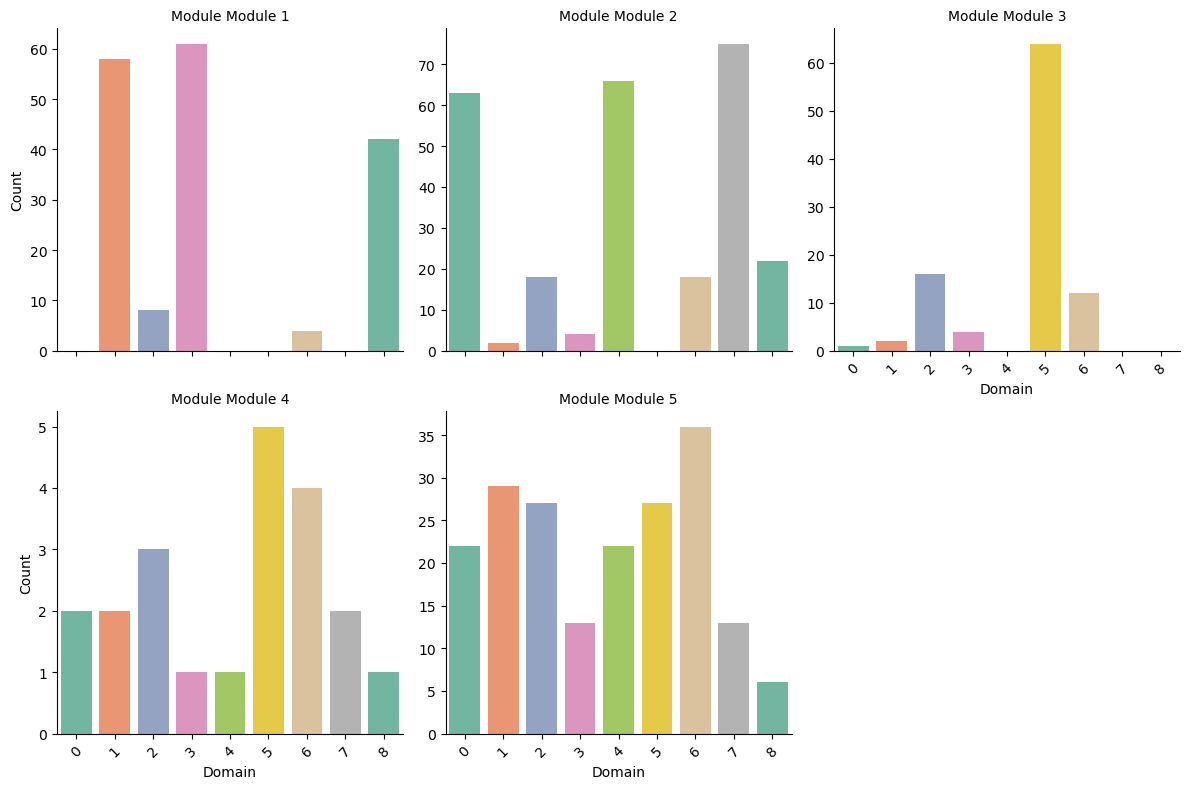

In [37]:
# Rename your existing result DataFrame
peak_module_domain_counts = result.copy()
peak_module_domain_counts.columns = [f'Module {i+1}' for i in range(peak_module_domain_counts.shape[1])]

# Convert to long-form DataFrame
barplot_data = (
    peak_module_domain_counts
    .reset_index()
    .melt(id_vars='index', var_name='Module', value_name='Peak Count')
    .rename(columns={'index': 'Spatial Domain'})
)

# Set order for cleaner plot
barplot_data['Module'] = pd.Categorical(barplot_data['Module'], categories=sorted(peak_module_domain_counts.columns), ordered=True)
barplot_data['Spatial Domain'] = pd.Categorical(barplot_data['Spatial Domain'], categories=sorted(peak_module_domain_counts.index), ordered=True)

# Generate the plot using seaborn
grid = sns.catplot(
    data=barplot_data,
    kind='bar',
    x='Spatial Domain',
    y='Peak Count',
    col='Module',
    col_wrap=3,
    height=4,
    aspect=1,
    palette='Set2',
    sharey=False
)

grid.set_titles("Module {col_name}")
grid.set_axis_labels("Domain", "Count")

# Rotate x-axis labels for readability
for ax in grid.axes.flatten():
    for tick_label in ax.get_xticklabels():
        tick_label.set_rotation(45)

plt.tight_layout()
plt.show()


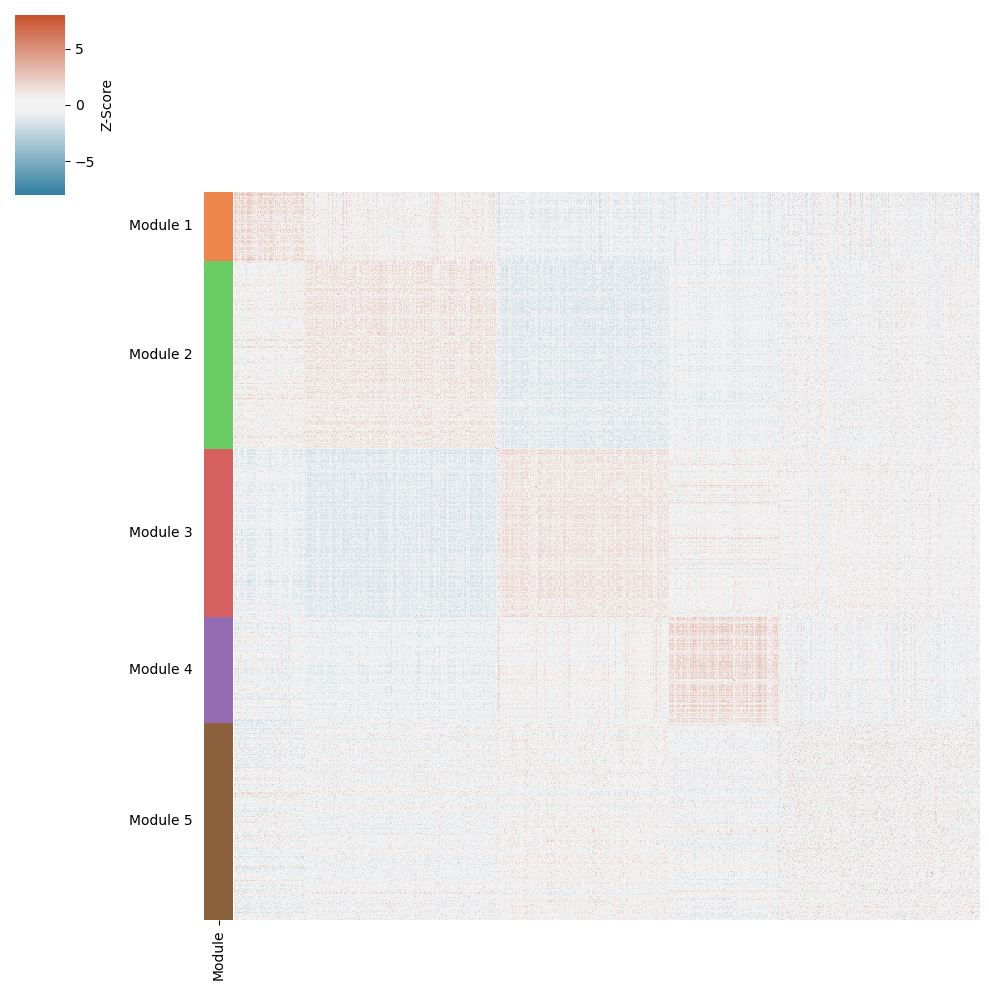

In [20]:
from scipy.cluster.hierarchy import leaves_list

pdist_z = scale(pdist_)
pdist_z = (pdist_z + pdist_z.T) / 2
results_z = pd.DataFrame(pdist_z)

ii = leaves_list(Z)
results_z = results_z.iloc[ii, ii]

label_indexed = pd.DataFrame(results_z, index=range(len(labels)))

sorted_results_z = label_indexed.loc[np.argsort(labels), np.argsort(labels)]

name_map = {}
next_mod = 1
for i in sorted_results_z.index:
    mod = labels[i]
    if mod in name_map:
        continue
    if mod == -1:
        continue
    else:
        name_map[int(mod)] = "Module {}".format(next_mod)
        next_mod = next_mod + 1
name_map[-1] = "Module 0"

name_map_r = {v: k for k, v in name_map.items()}

colors = sns.color_palette("muted")
colormap = {i: colors[i % 10] if i != -1 else (1.0, 1.0, 1.0) for i in np.unique(labels)}
colormap_r = {v: k for k, v in colormap.items()}
row_colors1 = pd.Series(
    [colormap[i] for i in labels],
    index=range(20000),
)

row_colors = pd.DataFrame({"Module": row_colors1})
row_colors = row_colors.loc[sorted_results_z.index]

cmap = sns.diverging_palette(230, 20, sep=20, s=85, l=50, as_cmap=True)

cm = sns.clustermap(
    sorted_results_z,
    row_cluster=False,
    col_cluster=False,
    vmin=-8,
    vmax=8,
    cmap=cmap,
    xticklabels=False,
    yticklabels=False,
    row_colors=row_colors,
    rasterized=True,
    cbar_kws=dict(
        label="Z-Score",
#         ticks=[-8, 0, 8],
    ),
)

fig = plt.gcf()
fig.patch.set_visible(False)
plt.sca(cm.ax_heatmap)
plt.ylabel("")
plt.xlabel("")

# Assuming row_colors is ordered, label the groups
plt.sca(cm.ax_row_colors)
for i in row_colors.Module.unique():
    if i == (1.0, 1.0, 1.0):
        continue
    mid = 0
    count = 0
    cl = colormap_r[i]
    for j, x in enumerate(row_colors.Module.values):
        if x == i:
            mid += j
            count += 1

    mid = mid/count

    plt.text(-.4, mid, name_map[cl],
             horizontalalignment='right',
             verticalalignment='center')

plt.show()

In [21]:
peak_modules = pd.Series(data=labels, index=atac.var_names[idx])  # or part of adata.var['module']

In [22]:
atac_10k = atac[:,idx].copy()

In [23]:
# x kb window
window = 50_000

# Prepare peak and gene DataFrames
peaks = atac_10k.var[['chrom', 'start', 'end']].copy()
peaks['peak_id'] = peaks.index
peaks['module'] = peak_modules.loc[peaks.index].values

genes = expr.var[['chrom', 'start', 'end']].copy()
genes['gene_id'] = genes.index

# Make sure coordinates are integers
peaks[['start', 'end']] = peaks[['start', 'end']].astype(int)
# Drop genes with missing coordinates
genes = genes.dropna(subset=['start', 'end'])

# Now safely cast to integers
genes[['start', 'end']] = genes[['start', 'end']].astype(int)
# Initialize output list
links = []

# Iterate chromosome by chromosome (faster, avoids cross-chromosome comparisons)
for chrom in peaks['chrom'].unique():
    peaks_chr = peaks[peaks['chrom'] == chrom]
    genes_chr = genes[genes['chrom'] == chrom]

    # For each peak, find genes within ±100 kb
    for i, peak in peaks_chr.iterrows():
        peak_center = (peak['start'] + peak['end']) // 2
        gene_subset = genes_chr[
            (genes_chr['start'] <= peak_center + window) &
            (genes_chr['end'] >= peak_center - window)
        ]
        for _, gene in gene_subset.iterrows():
            links.append({
                'peak_id': peak['peak_id'],
                'gene_id': gene['gene_id'],
                'module': peak['module'],
                'distance': min(abs(gene['start'] - peak_center), abs(gene['end'] - peak_center))
            })

# Convert to DataFrame
links_df = pd.DataFrame(links)


In [24]:
module_gene_map = links_df.groupby('module')['gene_id'].apply(set).to_dict()

In [25]:
def write_genes(m_g_map, r, num_clusters):
    
    # Create output directory if needed
    os.makedirs(f"{r}_{num_clusters}_module_gene_lists", exist_ok=True)
    
    # Write each module's gene list to a separate .txt file
    for module, genes in m_g_map.items():
        filename = f"{r}_{num_clusters}_module_gene_lists/module_{module}_genes.txt"
        with open(filename, 'w') as f:
            for gene in sorted(genes):  # sorted for readability
                f.write(f"{gene}\n")
        print(f"✅ Saved: {filename} ({len(genes)} genes)")

In [26]:
def write_peak_modules(peak_df, r, num_clusters):
    # Create output directory if needed
    os.makedirs(f"{r}_{num_clusters}_module_peak_beds_20k", exist_ok=True)

    for module_id in range(1, num_clusters+1):
        module_peaks = peak_df[peak_df['module'] == module_id]
    
        bed_df = module_peaks[['chrom', 'start', 'end', 'peak_id']].copy()
        bed_df['score'] = 0
        bed_df['strand'] = '.'
    
        bed_df.to_csv(
            f'{r}_{num_clusters}_module_peak_beds_20k/peak_module_{module_id}.bed',
            sep='\t',
            header=False,
            index=False
        )
    
        print(f"Wrote peak_module_{module_id}.bed with {len(bed_df)} peaks")

In [27]:
atac_all_peaks = sc.read_h5ad("../../h5ad_files/c_atac_spatial_peaks.h5ad")

In [28]:
bed = atac_all_peaks.var[["chrom", "start", "end"]].copy()
bed["name"] = atac_all_peaks.var_names  # optional, to preserve peak ID
bed = bed.reset_index(drop=True)

bed.to_csv("all_peaks.bed", sep="\t", header=False, index=False)

# Create output directory if needed
os.makedirs(f"{r}_{num_clusters}_module_peak_beds", exist_ok=True)

for module_id in range(1, num_clusters+1):
    module_peaks = peak_df[peak_df['module'] == module_id]

    bed_df = module_peaks[['chrom', 'start', 'end', 'peak_id']].copy()
    bed_df['score'] = 0
    bed_df['strand'] = '.'

    bed_df.to_csv(
        f'{r}_{num_clusters}_module_peak_beds/peak_module_{module_id}.bed',
        sep='\t',
        header=False,
        index=False
    )


In [29]:
write_peak_modules(peaks, r, 5)

Wrote peak_module_1.bed with 1885 peaks
Wrote peak_module_2.bed with 5162 peaks
Wrote peak_module_3.bed with 4625 peaks
Wrote peak_module_4.bed with 2916 peaks
Wrote peak_module_5.bed with 5412 peaks


In [30]:
#write_genes(module_gene_map, r, 5)

In [31]:
all_genes = expr.var_names  # or atac_all_peaks.var_names
'''
with open("enrichr_background_genes.txt", "w") as f:
    for gene in all_genes:
        f.write(f"{gene}\n")
'''

'\nwith open("enrichr_background_genes.txt", "w") as f:\n    for gene in all_genes:\n        f.write(f"{gene}\n")\n'

## Which celltypes are modules enriched in?

In [32]:
for module in sorted(peak_modules.unique()):
    peak_ids = peak_modules[peak_modules == module].index
    atac.obs[f'module_{module}_score'] = atac[:, peak_ids].X.mean(axis=1)


In [33]:
for module in sorted(peak_modules.unique()):
    print(atac.obs.groupby('subclass')[f'module_{module}_score'].mean().sort_values(ascending=False).head(5))


subclass
L6 CT      0.948501
L6 IT      0.736160
L5 ET      0.688521
L5 IT      0.685061
L2/3 IT    0.618748
Name: module_1_score, dtype: float32
subclass
L2/3 IT    0.795731
L4/5 IT    0.771258
L5 IT      0.750391
L6 IT      0.742025
L5 ET      0.658265
Name: module_2_score, dtype: float32
subclass
Oligo    1.160206
Astro    1.093864
Endo     1.043763
Peri     1.010167
OPC      1.007420
Name: module_3_score, dtype: float32
subclass
Endo     1.257827
PVM      0.933112
Peri     0.813814
SMC      0.767950
Micro    0.753097
Name: module_4_score, dtype: float32
subclass
Micro      0.752590
VLMC       0.742167
L4/5 IT    0.722682
Oligo      0.708881
L2/3 IT    0.708718
Name: module_5_score, dtype: float32


/tmp/ipykernel_368326/998575007.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(atac.obs.groupby('subclass')[f'module_{module}_score'].mean().sort_values(ascending=False).head(5))


## Motifs

In [38]:
import requests

from tqdm import tqdm


In [39]:
def get_jaspar_metadata(matrix_id):
    url = f"https://jaspar.elixir.no/api/v1/matrix/{matrix_id}/"
    r = requests.get(url)
    if r.status_code == 200:
        return r.json()
    return None

In [40]:
def process_fimo_df(path):
    df = pd.read_csv(
    path,
    sep="\t",
    comment="#",  # skip the "#" header comment line
    header=None,  # we’ll set headers manually
    names=[
        "motif_id",
        "sequence_name",
        "start",
        "stop",
        "strand",
        "score",
        "p_value",
        "q_value",
        "matched_sequence"
    ])

    df = df.sort_values("q_value")
    df = df[df["q_value"] <= 0.05]

    unique_ids = df["motif_id"].unique()

    # Collect metadata
    records = []
    for matrix_id in tqdm(unique_ids):
        data = get_jaspar_metadata(matrix_id)
        if data:
            records.append({
                "motif_id": matrix_id,
                "name": data.get("name"),
                "species": data.get("species"),
                "family": data.get("family"),
                "class": data.get("class")
            })
    
    meta_df = pd.DataFrame(records)
    
    # Merge back to FIMO hits
    df_annotated = df.merge(meta_df, on="motif_id", how="left")

    # Extract the first species name from the list of dicts
    df_annotated["species_name"] = df_annotated["species"].apply(
        lambda s: s[0]["name"] if isinstance(s, list) and len(s) > 0 else None
    )
    
    df_mouse = df_annotated[df_annotated["species_name"] == "Mus musculus"]
    
    df_mouse = df_mouse.drop(columns=["species", "family", "class"])
    
    df_mouse = df_mouse[df_mouse["q_value"] < 0.05]
    
    return df_mouse 

In [42]:
fimo_dfs = []

for i in range (1,6):
    fimo_dfs.append(process_fimo_df(f"./fimo_out_bg_module{i}_20k/fimo.txt"))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:09<00:00,  5.14it/s]


In [44]:
"thap11" in expr.var_names

True

In [43]:
for df in fimo_dfs:
    display(df)

,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
308,MA1573.2,chr17:24632437-24632936,234,247,-,23.5676,7.580000e-09,0.0139,ACTACAATTCCCAG,Thap11,Mus musculus
392,MA1573.2,chr7:29853347-29853846,327,340,+,22.0450,1.890000e-08,0.0173,ACTACATTTCCCAG,Thap11,Mus musculus
505,MA1573.2,chr4:148945480-148945979,274,287,+,21.7117,3.370000e-08,0.0206,ACTACATGTCCCAG,Thap11,Mus musculus
2081,MA0080.7,chr4:97127791-97128290,348,360,+,21.8560,1.520000e-08,0.0268,AAAGAGGAAGTGG,Spi1,Mus musculus
2092,MA0080.7,chr8:93840917-93841416,163,175,+,20.4880,3.090000e-08,0.0273,AAAGAGGAAGTGA,Spi1,Mus musculus
2124,MA1573.2,chr2:158730832-158731331,40,53,-,20.9459,6.070000e-08,0.0277,ACTACAACTCCCAC,Thap11,Mus musculus
2158,MA1573.2,chr5:32857701-32858200,345,358,-,20.4685,8.300000e-08,0.0287,ACTACACCTCCCAG,Thap11,Mus musculus
2159,MA1573.2,chr6:126735692-126736191,293,306,-,20.4234,9.410000e-08,0.0287,ACTACATATCCCAG,Thap11,Mus musculus
3387,MA0659.4,chr8:84025900-84026399,171,182,-,20.5417,5.710000e-08,0.0348,GCTGACTCAGCA,Mafg,Mus musculus
3388,MA0659.4,chr10:39412198-39412697,159,170,+,20.5417,5.710000e-08,0.0348,GCTGACTCAGCA,Mafg,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
8854,MA1573.2,chr7:19426420-19426919,94,107,+,22.0450,1.890000e-08,0.0314,ACTACATTTCCCAG,Thap11,Mus musculus
8856,MA1573.2,chr7:27979019-27979518,186,199,-,22.0450,1.890000e-08,0.0314,ACTACATTTCCCAG,Thap11,Mus musculus
8859,MA1573.2,chr19:26261492-26261991,125,138,+,22.0541,1.500000e-08,0.0314,ACTACATCTCCCAG,Thap11,Mus musculus
12146,MA1540.3,chr9:120010112-120010611,122,133,-,18.4895,1.210000e-07,0.0430,AGTTCAAGGCCA,NR5A1,Mus musculus
12148,MA1540.3,chr10:6930303-6930802,121,132,+,18.4895,1.210000e-07,0.0430,AGTTCAAGGCCA,NR5A1,Mus musculus
12149,MA1540.3,chr14:11562855-11563354,484,495,-,18.4895,1.210000e-07,0.0430,AGTTCAAGGCCA,NR5A1,Mus musculus
12151,MA1540.3,chr2:180495835-180496334,487,498,+,18.4895,1.210000e-07,0.0430,AGTTCAAGGCCA,NR5A1,Mus musculus
12152,MA1540.3,chr10:76358411-76358910,477,488,+,18.4895,1.210000e-07,0.0430,AGTTCAAGGCCA,NR5A1,Mus musculus
12153,MA1540.3,chr6:115903100-115903599,75,86,+,18.4895,1.210000e-07,0.0430,AGTTCAAGGCCA,NR5A1,Mus musculus
12154,MA1540.3,chr10:28856026-28856525,121,132,+,20.1538,6.190000e-08,0.0430,AGTTCAAGGTCA,NR5A1,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
484,MA1573.2,chr8:4677608-4678107,301,314,-,23.5766,3.710000e-09,0.00205,ACTACAACTCCCAG,Thap11,Mus musculus
485,MA1573.2,chr6:122308528-122309027,106,119,+,23.5766,3.710000e-09,0.00205,ACTACAACTCCCAG,Thap11,Mus musculus
486,MA1573.2,chr6:35133586-35134085,239,252,-,23.5766,3.710000e-09,0.00205,ACTACAACTCCCAG,Thap11,Mus musculus
487,MA1573.2,chr8:71468836-71469335,137,150,+,23.5766,3.710000e-09,0.00205,ACTACAACTCCCAG,Thap11,Mus musculus
488,MA1573.2,chr15:98867224-98867723,296,309,-,23.5766,3.710000e-09,0.00205,ACTACAACTCCCAG,Thap11,Mus musculus
...,...,...,...,...,...,...,...,...,...,...,...
94176,MA0506.3,chr2:137116657-137117156,118,129,+,14.0080,7.760000e-06,0.04870,AGGCGCATGCGC,Nrf1,Mus musculus
94185,MA0506.3,chr10:81105608-81106107,270,281,-,14.0080,7.760000e-06,0.04870,AGGCGCATGCGC,Nrf1,Mus musculus
95160,MA0506.3,chr6:97205465-97205964,296,307,-,13.9920,7.810000e-06,0.04890,CCGCGCCTGCTC,Nrf1,Mus musculus
95161,MA0506.3,chr10:36974134-36974633,123,134,-,13.9920,7.810000e-06,0.04890,CCGCGCCTGCTC,Nrf1,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
725,MA0145.2,chr17:72858169-72858668,342,355,+,18.6600,3.710000e-09,0.0103,CCAGTTCAAACCAG,Tfcp2l1,Mus musculus
730,MA1573.2,chr7:45830662-45831161,369,382,-,23.5766,3.710000e-09,0.0105,ACTACAACTCCCAG,Thap11,Mus musculus
764,MA1573.2,chr7:126780452-126780951,284,297,+,23.5676,7.580000e-09,0.0107,ACTACAATTCCCAG,Thap11,Mus musculus
887,MA0142.1,chr11:112811079-112811578,187,201,+,21.8198,4.190000e-09,0.0118,CATTGTCATGCAAAT,Pou5f1::Sox2,Mus musculus
1528,MA1573.2,chr2:166727917-166728416,413,426,+,22.0450,1.890000e-08,0.0134,ACTACATTTCCCAG,Thap11,Mus musculus
1535,MA1573.2,chr19:4257496-4257995,208,221,-,22.0450,1.890000e-08,0.0134,ACTACATTTCCCAG,Thap11,Mus musculus
2769,MA1540.3,chr8:25017739-25018238,95,106,+,18.4895,1.210000e-07,0.0228,AGTTCAAGGCCA,NR5A1,Mus musculus
2770,MA1540.3,chr2:180472876-180473375,132,143,-,18.4895,1.210000e-07,0.0228,AGTTCAAGGCCA,NR5A1,Mus musculus
2771,MA1540.3,chr5:115212800-115213299,115,126,-,18.4895,1.210000e-07,0.0228,AGTTCAAGGCCA,NR5A1,Mus musculus
2772,MA1540.3,chr6:83143380-83143879,112,123,-,18.4895,1.210000e-07,0.0228,AGTTCAAGGCCA,NR5A1,Mus musculus


,motif_id,sequence_name,start,stop,strand,score,p_value,q_value,matched_sequence,name,species_name
854,MA1573.2,chr10:127522080-127522579,413,426,-,23.5676,7.580000e-09,0.00665,ACTACAATTCCCAG,Thap11,Mus musculus
855,MA1573.2,chr8:84965869-84966368,306,319,-,23.5676,7.580000e-09,0.00665,ACTACAATTCCCAG,Thap11,Mus musculus
856,MA1573.2,chr19:38258632-38259131,102,115,-,23.5676,7.580000e-09,0.00665,ACTACAATTCCCAG,Thap11,Mus musculus
857,MA1573.2,chr7:45589091-45589590,164,177,-,23.5766,3.710000e-09,0.00665,ACTACAACTCCCAG,Thap11,Mus musculus
858,MA1573.2,chr2:144550498-144550997,370,383,-,23.5676,7.580000e-09,0.00665,ACTACAATTCCCAG,Thap11,Mus musculus
860,MA1573.2,chr9:57439847-57440346,341,354,-,23.5766,3.710000e-09,0.00665,ACTACAACTCCCAG,Thap11,Mus musculus
1262,MA1573.2,chr7:24207852-24208351,350,363,+,22.0450,1.890000e-08,0.01100,ACTACATTTCCCAG,Thap11,Mus musculus
1263,MA1573.2,chr5:142935531-142936030,279,292,-,22.0541,1.500000e-08,0.01100,ACTACATCTCCCAG,Thap11,Mus musculus
1266,MA1573.2,chr2:30590739-30591238,295,308,+,22.0450,1.890000e-08,0.01100,ACTACATTTCCCAG,Thap11,Mus musculus
1712,MA1573.2,chr1:135373089-135373588,407,420,-,21.9459,2.630000e-08,0.01380,ACTACAAATCCCAG,Thap11,Mus musculus


In [ ]:
# Make a directory to store the output files
os.makedirs("enrichr_input", exist_ok=True)

# Iterate over your list of FIMO DataFrames
for i, df in enumerate(fimo_dfs):
    # Get unique TF names (gene symbols), drop NAs, sort alphabetically
    tf_symbols = df['name'].dropna().unique()
    tf_symbols.sort()
    
    # Define filename: one per module
    filename = f"enrichr_input/module_{i+1}_tfs.txt"
    
    # Write to file
    with open(filename, "w") as f:
        for symbol in tf_symbols:
            f.write(symbol + "\n")

    print(f"Wrote {len(tf_symbols)} TFs to {filename}")
